TF version: 2.20.0
GPUs: []


((60000, 28, 28, 1), (60000,), (10000, 28, 28, 1), (10000,))

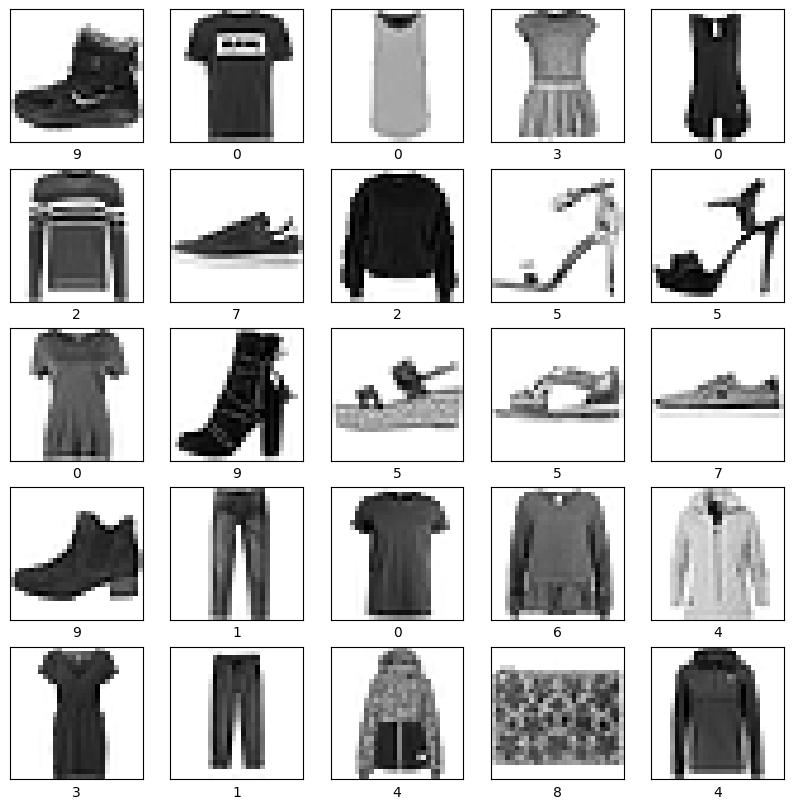

In [30]:
# Implement a ResNet-34 CNN model using Keras

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))



np.random.seed(42)

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

x_train = x_train[..., np.newaxis] / 255.0
x_test  = x_test[..., np.newaxis] / 255.0

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])

x_train.shape, y_train.shape, x_test.shape, y_test.shape



In [31]:
from functools import partial

DefaultConv2D = partial(keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="SAME", use_bias=False)

class ResidualUnit(keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = keras.activations.get(activation)
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            keras.layers.BatchNormalization()]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                keras.layers.BatchNormalization()]

    def call(self, inputs):
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)

In [32]:
model = keras.models.Sequential()
model.add(DefaultConv2D(64, kernel_size=3, strides=1, input_shape=[28,28,1]))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation("relu"))
prev_filters = 64
for filters in [16]*3 + [32]*4 + [64]*6 + [128]*3:
    strides = 1 if filters == prev_filters else 2
    model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters
model.add(keras.layers.GlobalAvgPool2D())
model.add(keras.layers.Dense(10, activation="softmax"))

model.summary()

c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_182 (Conv2D)             │ (None, 28, 28, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_182         │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_80 (ResidualUnit) │ (None, 14, 14, 16)     │        12,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_81 (ResidualUnit) │ (None, 14, 14, 16)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_82 (ResidualUnit) │ (None, 14, 14, 16)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_83 (ResidualUnit) │ (None, 7, 7, 32)       │        14,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_84 (ResidualUnit) │ (None, 7, 7, 32)       │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_85 (ResidualUnit) │ (None, 7, 7, 32)       │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_86 (ResidualUnit) │ (None, 7, 7, 32)       │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_87 (ResidualUnit) │ (None, 4, 4, 64)       │        58,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_88 (ResidualUnit) │ (None, 4, 4, 64)       │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_89 (ResidualUnit) │ (None, 4, 4, 64)       │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_90 (ResidualUnit) │ (None, 4, 4, 64)       │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_91 (ResidualUnit) │ (None, 4, 4, 64)       │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_92 (ResidualUnit) │ (None, 4, 4, 64)       │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_93 (ResidualUnit) │ (None, 2, 2, 128)      │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_94 (ResidualUnit) │ (None, 2, 2, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_95 (ResidualUnit) │ (None, 2, 2, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,347,210 (5.14 MB)

 Trainable params: 1,342,826 (5.12 MB)

 Non-trainable params: 4,384 (17.12 KB)

In [ ]:
opt = keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)


model.compile(loss="sparse_categorical_crossentropy",
              optimizer=opt,
                metrics=["accuracy"])

history = model.fit(x_train, y_train, epochs=50, batch_size=128,
                    validation_data=(x_test, y_test),
                    callbacks=[early_stopping_cb])


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 175s 335ms/step - accuracy: 0.7621 - loss: 0.6907 - val_accuracy: 0.8015 - val_loss: 0.5592
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 145s 310ms/step - accuracy: 0.8706 - loss: 0.3529 - val_accuracy: 0.8559 - val_loss: 0.3786
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 146s 310ms/step - accuracy: 0.8870 - loss: 0.3033 - val_accuracy: 0.8743 - val_loss: 0.3415
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 292ms/step - accuracy: 0.8995 - loss: 0.2712 - val_accuracy: 0.8819 - val_loss: 0.3185
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 291ms/step - accuracy: 0.9057 - loss: 0.2489 - val_accuracy: 0.8809 - val_loss: 0.3274
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 146s 312ms/step - accuracy: 0.9140 - loss: 0.2269 - val_accuracy: 0.8985 - val_loss: 0.2789
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 295ms/step - accuracy: 0.9213 - loss: 0.2104 - val_accuracy: 0.8974 - val_loss: 0.2911
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 147s 314ms/step - accuracy: 0.9259 -

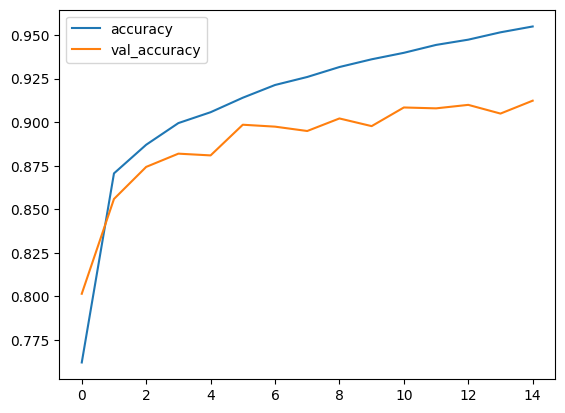

In [34]:
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.legend()